In [2]:
# 05_family_hierarchical.ipynb

# 1. DATA LOADING

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Load preprocessed data
df = pd.read_csv("preprocessed_customer_data.csv")

In [3]:
# 2. FEATURE SELECTION (FAMILY BEHAVIOR)

family_features = [
    'Kidhome', 'Teenhome', 'MntMeatProducts', 'MntFruits',
    'MntSweetProducts', 'MntFishProducts'
]
X = df[family_features]

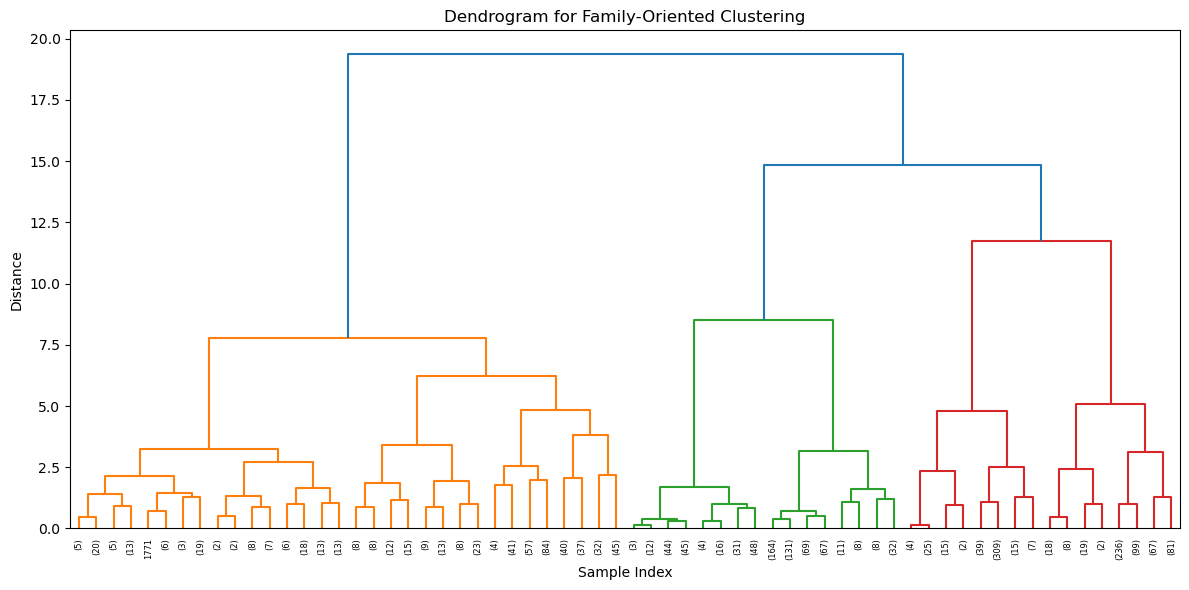

In [6]:
# 3. DENDROGRAM TO DECIDE CLUSTER NUMBER

linkage_matrix = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title("Dendrogram for Family-Oriented Clustering")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [8]:
# 4. APPLY AGNES (AGGLOMERATIVE CLUSTERING)

optimal_k = 3  # Adjust this based on dendrogram observation
agnes = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['FamilyCluster_AGNES'] = agnes.fit_predict(X)

# Evaluate clustering quality
score = silhouette_score(X, df['FamilyCluster_AGNES'])
print(f"Silhouette Score (AGNES, k={optimal_k}): {score:.4f}")

Silhouette Score (AGNES, k=3): 0.3756



📊 Average Family & Product Spending per Cluster:


,Kidhome,Teenhome,MntMeatProducts,MntFruits,MntSweetProducts,MntFishProducts
FamilyCluster_AGNES,,,,,,
0,0.255285,0.514799,0.044439,0.052296,0.040097,0.052062
1,0.005199,0.126516,0.256101,0.357942,0.286352,0.406697
2,0.353535,0.000000,0.035671,0.054094,0.036730,0.054996


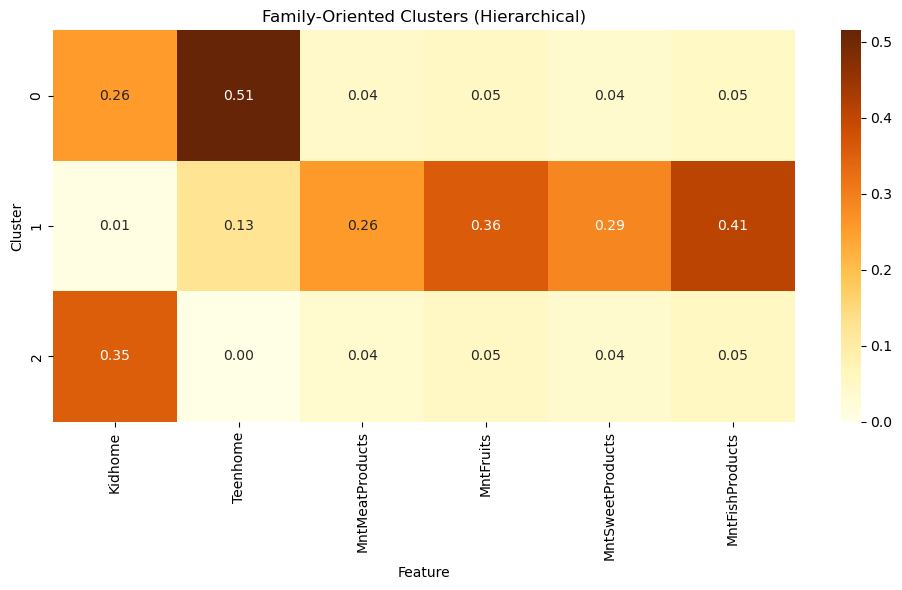

In [10]:
# 5. CLUSTER PROFILE ANALYSIS

cluster_profile = df.groupby('FamilyCluster_AGNES')[family_features].mean()
print("\n📊 Average Family & Product Spending per Cluster:")
display(cluster_profile)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlOrBr", fmt=".2f")
plt.title("Family-Oriented Clusters (Hierarchical)")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

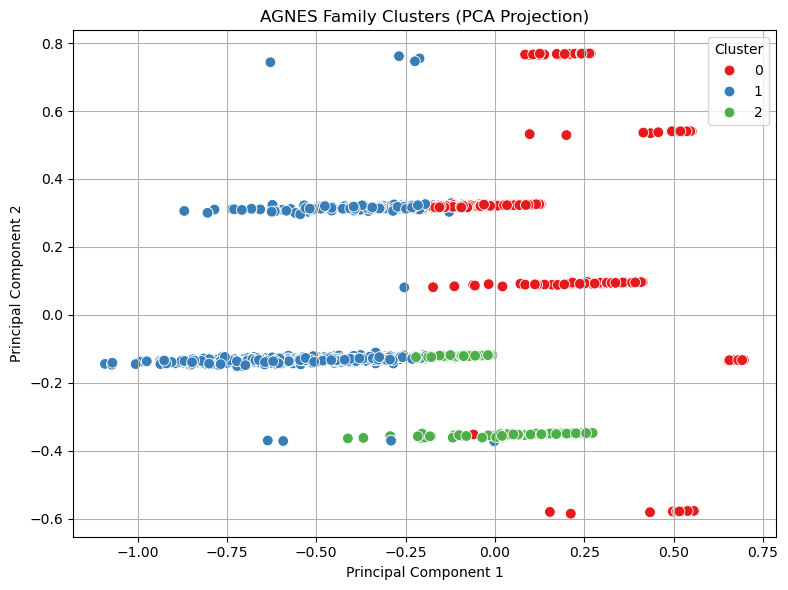

In [12]:
# 6. VISUALIZE CLUSTERS USING PCA (2D)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['FamilyCluster_AGNES']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=60)
plt.title("AGNES Family Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()